# ANALYSIS

In [1]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import re
from pathlib import Path

In [2]:
BASE_DIR = Path('/scratch/saporito/Frag3D')
FINAL_STEP = 'step_36533'
MASS_THRESHOLD = 1e-6

SIM_FOLDERS = [
    'sim_vel1.0e+03_sf4.0e-01_T4.0e-05_k2.0e-01_sh_gaussian_thxy0.0e+00_thz0.0e+00_sgn1.0e+00_cntr_0.0e+00_0.0e+00',
    'sim_vel1.0e+03_sf4.0e-01_T4.0e-05_k2.0e-01_sh_gaussian_thxy0.0e+00_thz0.0e+00_sgn1.0e+00_cntr_1.5e-02_0.0e+00',
    'sim_vel1.0e+03_sf4.0e-01_T4.0e-05_k2.0e-01_sh_gaussian_thxy0.0e+00_thz0.0e+00_sgn1.0e+00_cntr_1.5e-02_1.5e-02',
    'sim_vel1.0e+03_sf4.0e-01_T4.0e-05_k2.0e-01_sh_gaussian_thxy0.0e+00_thz0.0e+00_sgn1.0e+00_cntr_2.5e-02_2.5e-02'
]

def make_label(folder: str) -> str:
    m_vel  = re.search(r'vel([^_]+)', folder)
    m_k    = re.search(r'_k([^_]+)', folder)
    m_sh   = re.search(r'sh_([a-zA-Z]+)', folder)
    
    m_thxy = re.search(r'thxy([^_]+)', folder)
    m_thz  = re.search(r'thz([^_]+)',  folder)
    m_cntr = re.search(r'cntr_([0-9.e+\-]+)_([0-9.e+\-]+)', folder)
    
    vel  = float(m_vel.group(1)) if m_vel else 0.0
    k    = float(m_k.group(1)) if m_k else 0.0
    sh   = m_sh.group(1) if m_sh else 'unknown'
    
    thxy   = float(m_thxy.group(1)) if m_thxy else 0
    thz    = float(m_thz.group(1))  if m_thz  else 0
    cx, cy = (float(m_cntr.group(1)), float(m_cntr.group(2))) if m_cntr else (0, 0)
    
    return f'vel={vel:.1e} k={k:.2f} sh={sh} | thxy={thxy:.0f}° thz={thz:.0f}° | cntr=({cx:.2g},{cy:.2g})'

LABELS = [make_label(f) for f in SIM_FOLDERS]
COLORS = plt.cm.tab10(np.linspace(0, 0.5, len(SIM_FOLDERS)))

print('Simulation labels:')
for i, lbl in enumerate(LABELS):
    print(f'  [{i}] {lbl}')

Simulation labels:
  [0] vel=1.0e+03 k=0.20 sh=gaussian | thxy=0° thz=0° | cntr=(0,0)
  [1] vel=1.0e+03 k=0.20 sh=gaussian | thxy=0° thz=0° | cntr=(0.015,0)
  [2] vel=1.0e+03 k=0.20 sh=gaussian | thxy=0° thz=0° | cntr=(0.015,0.015)
  [3] vel=1.0e+03 k=0.20 sh=gaussian | thxy=0° thz=0° | cntr=(0.025,0.025)


## 1 - Load final-step data for all simulations

In [3]:
SCALAR_ATTRS = ['econ', 'edis', 'ekin', 'epot', 'erev', 'nb_fragments', 'total_energy', 'work']

scalar_rows = []
fragment_data = {}

for folder, label in zip(SIM_FOLDERS, LABELS):
    h5path = BASE_DIR / folder / 'data.h5'
    with h5py.File(h5path, 'r') as f:
        step = f[FINAL_STEP]

        row = {'sim': label}
        for attr in SCALAR_ATTRS:
            row[attr] = float(step.attrs[attr])
        masses = step['fragment_mass'][:]
        vels   = step['fragment_velocity'][:]

        row['nb_fragments_heavy'] = int((masses >= MASS_THRESHOLD).sum())
        scalar_rows.append(row)

        vmag = np.linalg.norm(vels, axis=1)
        fragment_data[label] = {
            'mass':   masses,
            'vmag':   vmag,
            'vx':     vels[:, 0],
            'vy':     vels[:, 1],
            'vz':     vels[:, 2],
        }

print('Done loading', len(scalar_rows), 'simulations.')

Done loading 4 simulations.


## 2 - Energetics table

In [4]:
df_scalar = pd.DataFrame(scalar_rows).set_index('sim')

col_order = ['econ', 'edis', 'ekin', 'epot', 'erev', 'total_energy', 'work',
             'nb_fragments', 'nb_fragments_heavy']
df_scalar = df_scalar[col_order]

col_names = {
    'econ':               'E_con',
    'edis':               'E_dis',
    'ekin':               'E_kin',
    'epot':               'E_pot',
    'erev':               'E_rev',
    'total_energy':       'E_tot',
    'work':               'Work',
    'nb_fragments':       'N_frags',
    'nb_fragments_heavy': f'N_frags (m≥{MASS_THRESHOLD:.0e})',
}
df_display = df_scalar.rename(columns=col_names)

pd.set_option('display.float_format', '{:.4e}'.format)
pd.set_option('display.max_colwidth', None)
display(df_display)

,E_con,E_dis,E_kin,E_pot,E_rev,E_tot,Work,N_frags,N_frags (m≥1e-06)
sim,,,,,,,,,
"vel=1.0e+03 k=0.20 sh=gaussian | thxy=0° thz=0° | cntr=(0,0)",0.0000e+00,9.3832e-02,8.6589e+01,2.1341e-01,2.1437e-04,8.6896e+01,0.0000e+00,7.4081e+04,168
"vel=1.0e+03 k=0.20 sh=gaussian | thxy=0° thz=0° | cntr=(0.015,0)",0.0000e+00,8.2071e-02,8.6383e+01,1.9558e-01,1.5378e-04,8.6661e+01,0.0000e+00,6.6268e+04,153
"vel=1.0e+03 k=0.20 sh=gaussian | thxy=0° thz=0° | cntr=(0.015,0.015)",0.0000e+00,7.3294e-02,8.6182e+01,1.7839e-01,1.0093e-04,8.6433e+01,0.0000e+00,6.2876e+04,90
"vel=1.0e+03 k=0.20 sh=gaussian | thxy=0° thz=0° | cntr=(0.025,0.025)",0.0000e+00,2.1697e-02,2.1647e+01,5.3522e-02,3.4254e-05,2.1722e+01,0.0000e+00,1.7660e+04,30


## 3 - Fragment statistics table  
mean / max / min / std of mass, |v|, vx, vy, vz

In [5]:
def filter_fragment_data(fragment_data, mass_threshold):
    filtered_data = {}

    for label, fd in fragment_data.items():

        mask = fd['mass'] > mass_threshold

        filtered_data[label] = {
            key: values[mask]
            for key, values in fd.items()
        }

    return filtered_data

fragment_data = filter_fragment_data(
    fragment_data,
    MASS_THRESHOLD
)

In [6]:
FRAG_KEYS   = ['mass', 'vmag', 'vx', 'vy', 'vz']
FRAG_LABELS = ['Mass', '|v|', 'vx', 'vy', 'vz']
STAT_FUNCS  = {'mean': np.mean, 'min': np.min, 'max': np.max, 'std': np.std}

rows = []
idx  = []
for label in LABELS:
    fd = fragment_data[label]
    for key, name in zip(FRAG_KEYS, FRAG_LABELS):
        arr = fd[key]
        row = {stat: fn(arr) for stat, fn in STAT_FUNCS.items()}
        rows.append(row)
        idx.append((label, name))

df_stats = pd.DataFrame(rows, index=pd.MultiIndex.from_tuples(idx, names=['sim', 'quantity']))
display(df_stats)

mean  \
sim                                                                  quantity               
vel=1.0e+03 k=0.20 sh=gaussian | thxy=0° thz=0° | cntr=(0,0)         Mass      7.5676e-05   
                                                                     |v|       3.1818e+02   
                                                                     vx       -4.2049e-01   
                                                                     vy        8.2571e-01   
                                                                     vz        3.1778e+02   
vel=1.0e+03 k=0.20 sh=gaussian | thxy=0° thz=0° | cntr=(0.015,0)     Mass      8.5028e-05   
                                                                     |v|       2.1347e+02   
                                                                     vx        4.5185e-01   
                                                                     vy        9.5939e-01   
                                                                     vz        2.1232e+02   
vel=1.0e+03 k=0.20 sh=gaussian | thxy=0° thz=0° | cntr=(0.015,0.015) Mass      1.4716e-04   
                                                                     |v|       3.8471e+02   
                                                                     vx        1.3563e+00   
                                                                     vy        2.3258e-02   
                                                                     vz        3.8435e+02   
vel=1.0e+03 k=0.20 sh=gaussian | thxy=0° thz=0° | cntr=(0.025,0.025) Mass      5.1826e-04   
                                                                     |v|       1.4213e+02   
                                                                     vx        1.3834e+00   
                                                                     vy        1.8915e+00   
                                                                     vz        1.4018e+02   

                                                                                      min  \
sim                                                                  quantity               
vel=1.0e+03 k=0.20 sh=gaussian | thxy=0° thz=0° | cntr=(0,0)         Mass      1.0192e-06   
                                                                     |v|       6.3524e+00   
                                                                     vx       -2.1303e+01   
                                                                     vy       -2.2761e+01   
                                                                     vz        3.6919e+00   
vel=1.0e+03 k=0.20 sh=gaussian | thxy=0° thz=0° | cntr=(0.015,0)     Mass      1.0064e-06   
                                                                     |v|       2.7861e+00   
                                                                     vx       -1.4677e+01   
                                                                     vy       -2.6721e+01   
                                                                     vz       -1.1974e+01   
vel=1.0e+03 k=0.20 sh=gaussian | thxy=0° thz=0° | cntr=(0.015,0.015) Mass      1.0016e-06   
                                                                     |v|       2.7423e-01   
                                                                     vx       -1.5691e+01   
                                                                     vy       -1.4740e+01   
                                                                     vz        2.5704e-01   
vel=1.0e+03 k=0.20 sh=gaussian | thxy=0° thz=0° | cntr=(0.025,0.025) Mass      1.2742e-06   
                                                                     |v|       2.3816e-01   
                                                                     vx       -9.1327e+00   
                                                                     vy       -1.3651e+01   
                                                                     vz       -3.7188

## 4 - Distribution plots

In [7]:
from scipy.stats import gaussian_kde

def kde_line(ax, arr, color, label, log_x=False, bw_method='scott'):
    data = arr[arr > 0] if log_x else arr
    if len(data) < 2:
        return
    try:
        if log_x:
            log_data = np.log10(data)
            if np.ptp(log_data) == 0:
                return
            kde = gaussian_kde(log_data, bw_method=bw_method)
            xs_log = np.linspace(log_data.min(), log_data.max(), 500)
            ys = kde(xs_log) / np.log(10)
            xs = 10 ** xs_log
        else:
            if np.ptp(data) == 0:
                return
            kde = gaussian_kde(data, bw_method=bw_method)
            xs = np.linspace(data.min(), data.max(), 500)
            ys = kde(xs)
        ax.plot(xs, ys, color=color, label=label, linewidth=1.8)
        ax.fill_between(xs, ys, alpha=0.12, color=color)
    except Exception:
        return


def plot_kde_combined(frag_data, labels, colors, key, xlabel, log_x=False):
    fig, ax = plt.subplots(figsize=(9, 4))
    for label, color in zip(labels, colors):
        if label in frag_data:
            kde_line(ax, frag_data[label][key], color, label, log_x)
            
    if log_x:
        ax.set_xscale('log')
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel('Probability density', fontsize=11)
    ax.set_title(f'Distribution of {xlabel} - all configs', fontsize=12)
    
    handles, legend_labels = ax.get_legend_handles_labels()
    if handles:
        ax.legend(fontsize=7, framealpha=0.5)
        
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2e'))
    plt.tight_layout()
    plt.show()


def plot_kde_individual(frag_data, labels, colors, key, xlabel, log_x=False):
    valid_mins = []
    valid_maxs = []
    
    for lbl in labels:
        if lbl in frag_data:
            arr = frag_data[lbl][key]
            data = arr[arr > 0] if log_x else arr
            if len(data) >= 2 and np.ptp(data) > 0:
                valid_mins.append(data.min())
                valid_maxs.append(data.max())
                
    if not valid_mins:
        print(f"Skipping individual plots for {xlabel}: Not enough valid data points.")
        return
        
    xmin, xmax = min(valid_mins), max(valid_maxs)
    
    for label, color in zip(labels, colors):
        if label not in frag_data:
            continue
            
        arr = frag_data[label][key]
        data = arr[arr > 0] if log_x else arr
        if len(data) < 2:
            continue
            
        fig, ax = plt.subplots(figsize=(5, 4))
        kde_line(ax, frag_data[label][key], color, label=None, log_x=log_x)
        
        if log_x:
            ax.set_xscale('log')
        ax.set_xlim(xmin, xmax)
        ax.set_title(label, fontsize=8, wrap=True)
        ax.set_xlabel(xlabel, fontsize=9)
        ax.set_ylabel('Probability density', fontsize=10)
        ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2e'))
        plt.tight_layout()
        plt.show()

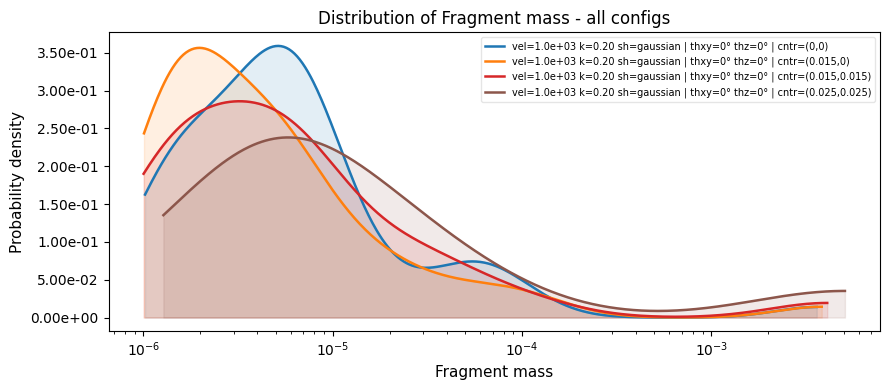

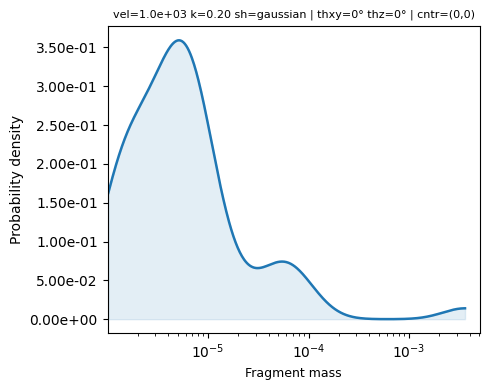

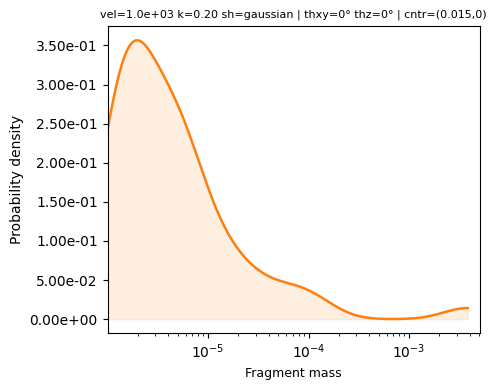

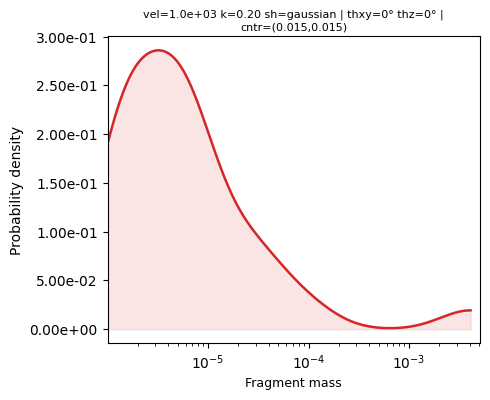

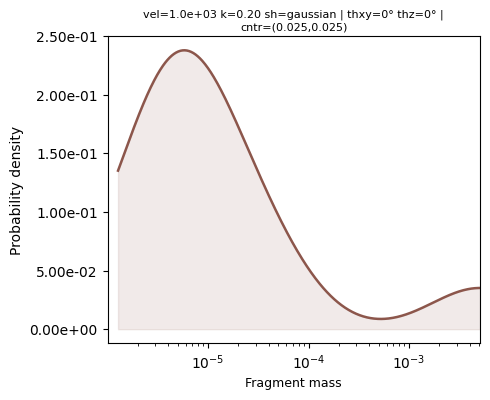

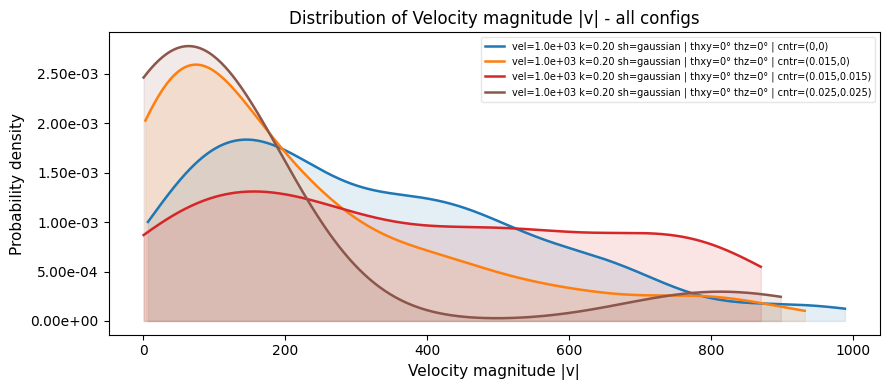

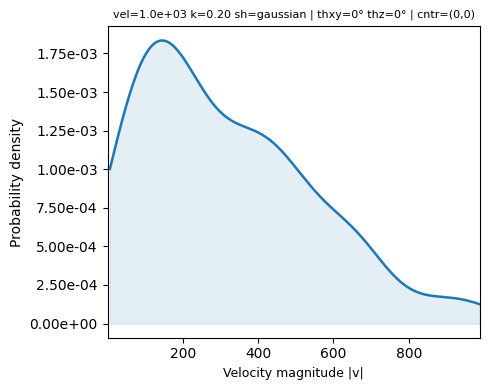

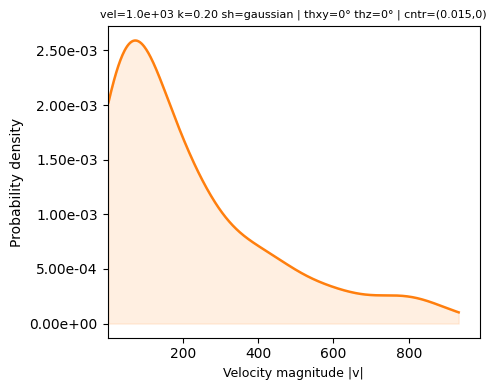

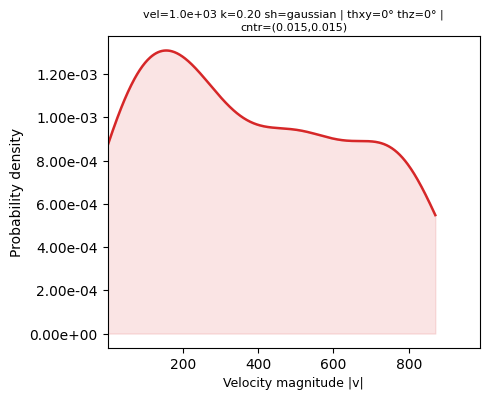

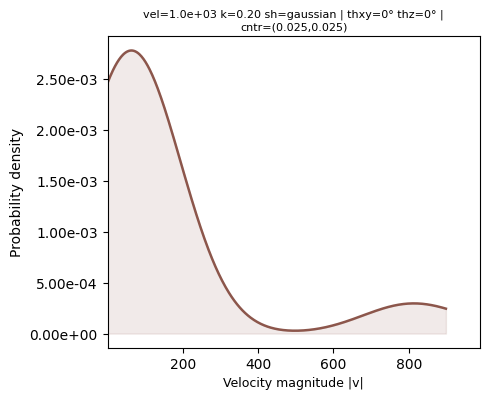

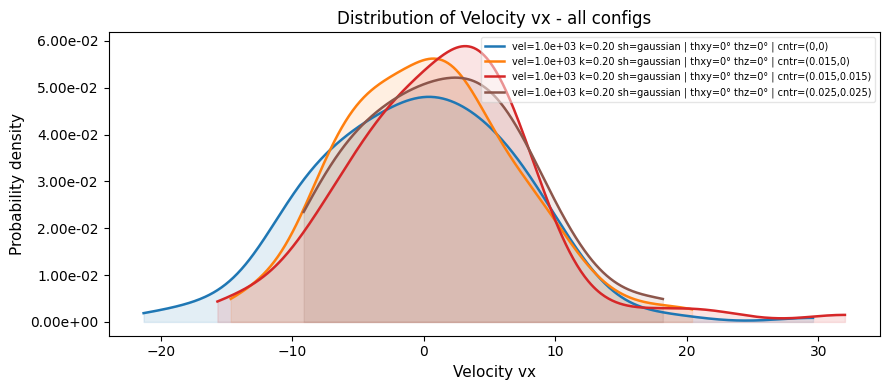

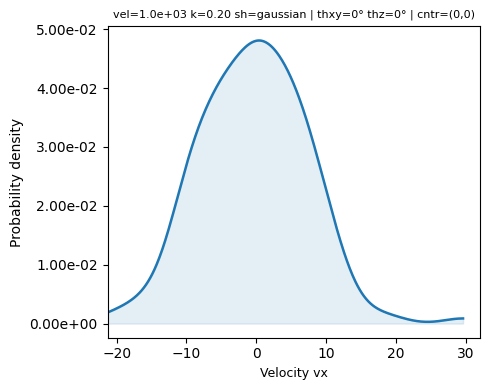

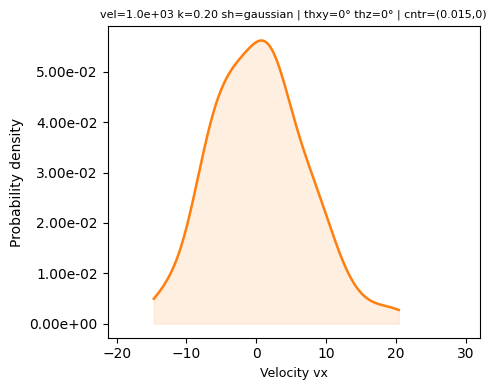

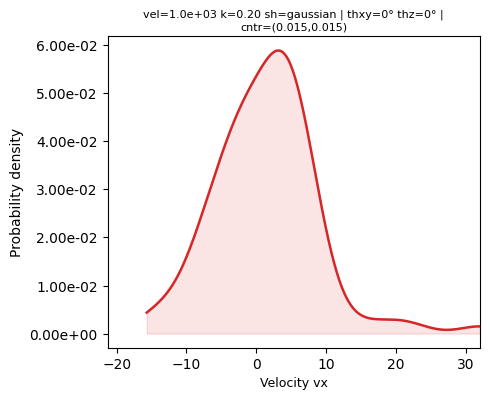

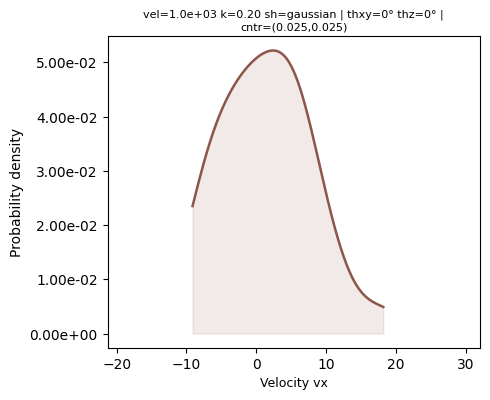

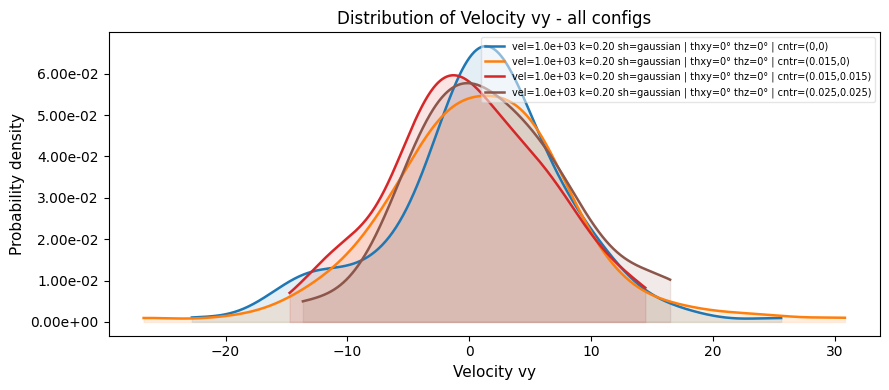

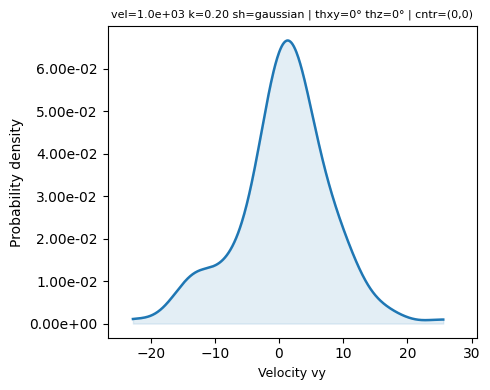

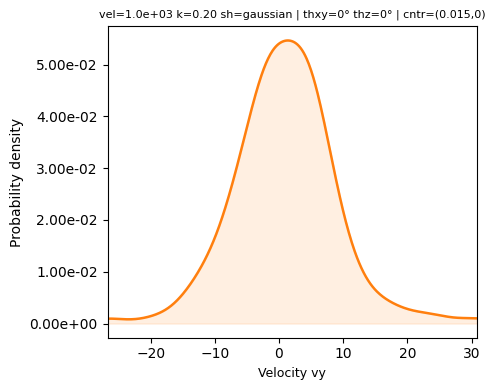

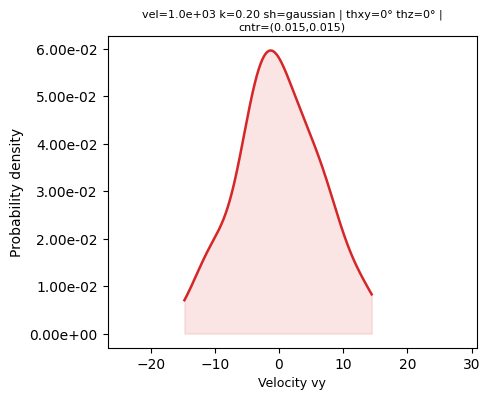

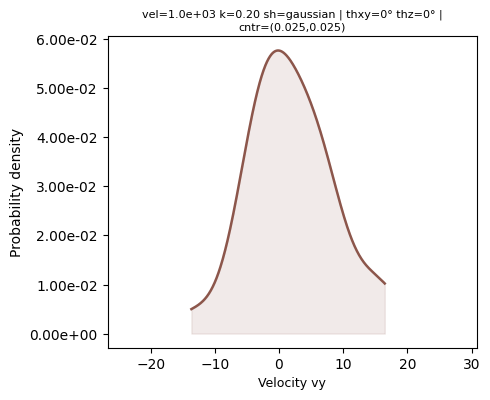

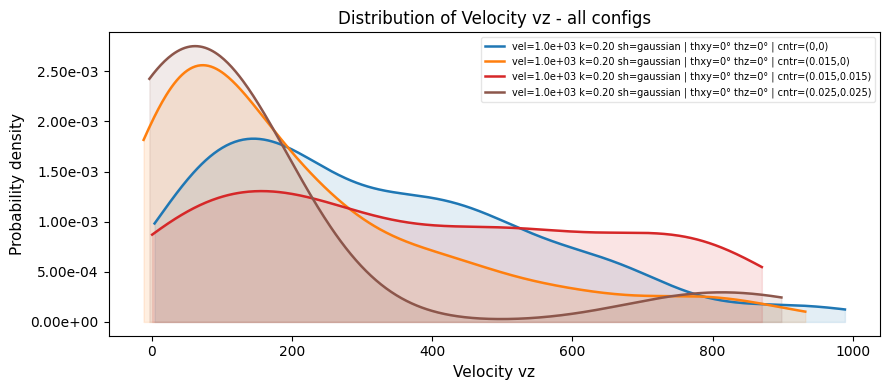

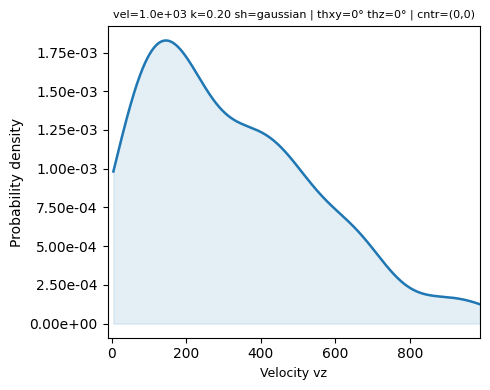

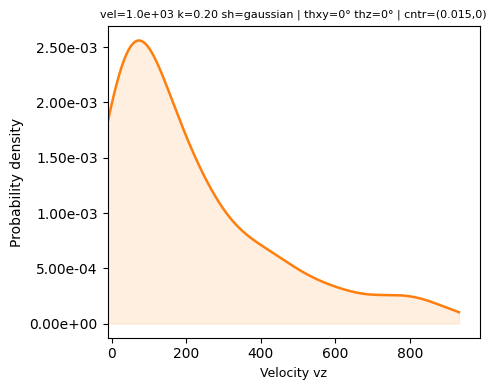

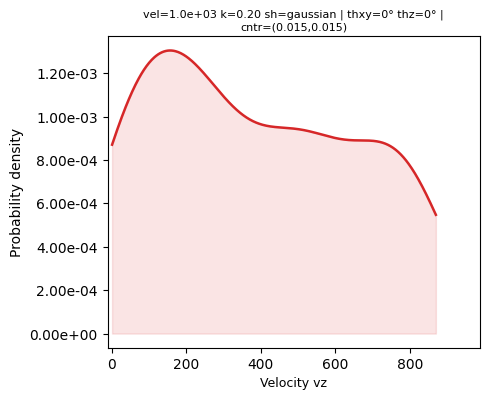

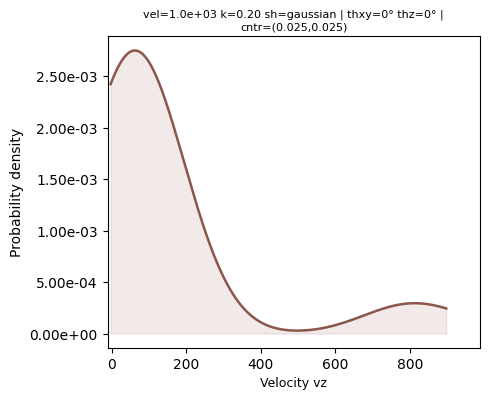

In [8]:
for key, xlabel, log_x in [
    ('mass', 'Fragment mass',          True),
    ('vmag', 'Velocity magnitude |v|', False),
    ('vx',   'Velocity vx',           False),
    ('vy',   'Velocity vy',           False),
    ('vz',   'Velocity vz',           False),
]:
    plot_kde_combined(fragment_data, LABELS, COLORS, key, xlabel, log_x)
    plot_kde_individual(fragment_data, LABELS, COLORS, key, xlabel, log_x)

## 5 - Scatter plot: velocity magnitude vs fragment mass

In [9]:
def scatter_vmag_vs_mass(frag_data, labels, colors, title_suffix='', ax=None):
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(7, 4.5))
        
    for label, color in zip(labels, colors):
        if label in frag_data:
            fd = frag_data[label]
            if len(fd['mass']) == 0: 
                continue
            ax.scatter(fd['mass'], fd['vmag'], s=20, alpha=0.5,
                       color=color, label=label, linewidths=0)
                       
    ax.set_xscale('log')
    ax.set_xlabel('Fragment mass', fontsize=10)
    ax.set_ylabel('Velocity magnitude |v|', fontsize=10)
    ax.set_title(f'|v| vs mass{title_suffix}', fontsize=11)
    
    if standalone:
        handles, legend_labels = ax.get_legend_handles_labels()
        if handles:
            ax.legend(fontsize=7, framealpha=0.5)
        plt.tight_layout()
        plt.show()

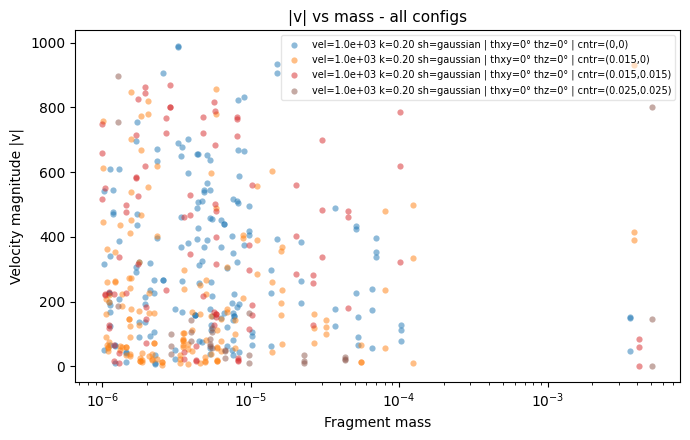

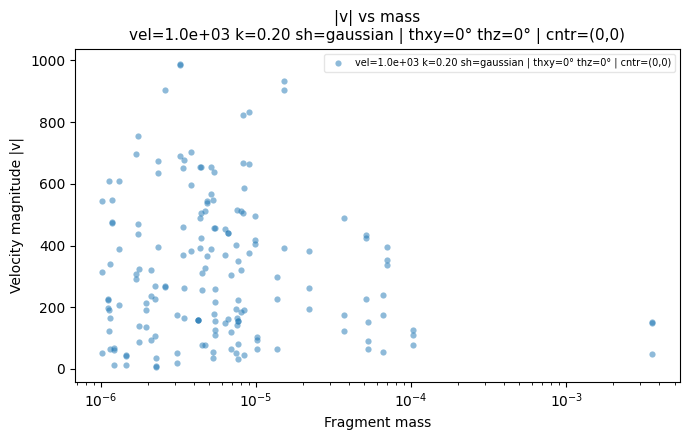

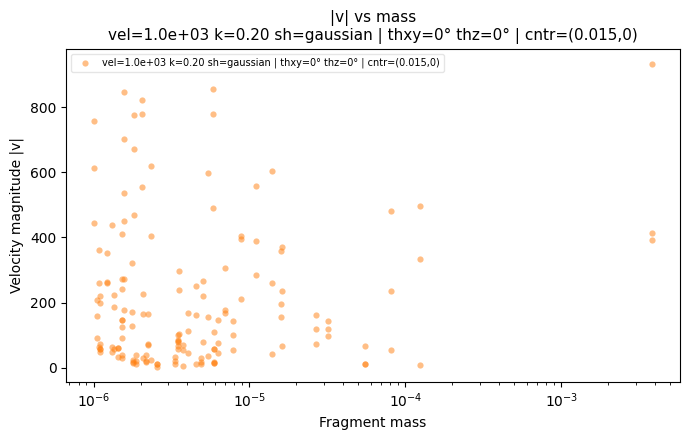

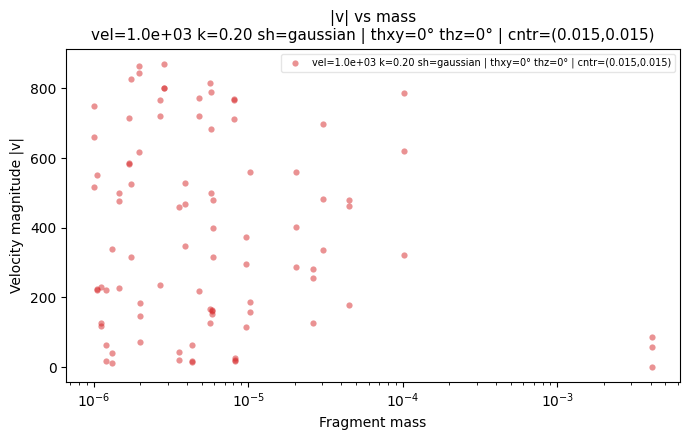

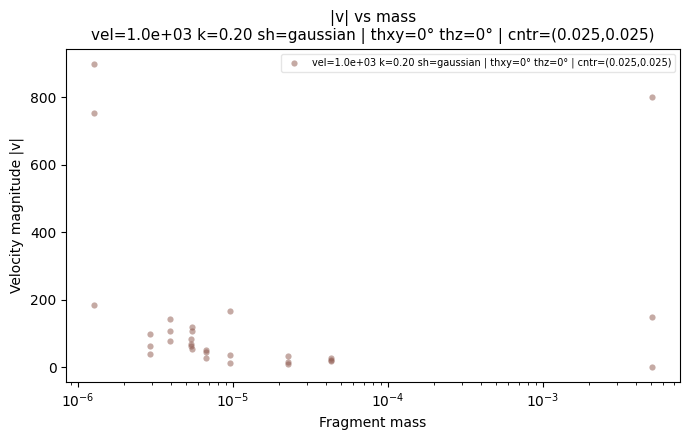

In [10]:
scatter_vmag_vs_mass(
    fragment_data,
    LABELS,
    COLORS,
    title_suffix=' - all configs'
)

for label, color in zip(LABELS, COLORS):
    if label in fragment_data and len(fragment_data[label]['mass']) > 0:
        scatter_vmag_vs_mass(
            fragment_data,
            [label],
            [color],
            title_suffix=f'\n{label}'
        )